In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

sns.set(style="whitegrid")

In [2]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("textdetox/multilingual_toxic_spans", split="ru")

C:\Users\valentin\.conda\envs\mirea-torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.DataFrame(ds)

In [4]:
df.head()

,Sentence,Negative Connotations
0,во дебил ты пан-баран))))))))))))))))))). евре...,"дебил, пан-баран, еврейское тв, даун"
1,завтра в хабаровске вдвшники будут разгонять б...,быдло
2,"эта походу старое фото,в середине хряк телепуз...","хряк, телепузик, редкая скотина"
3,а что рядом других что мужиков рядом не оказал...,"ублюдку, табло, перевелись"
4,"хули вы бляди клянчите классы ,просто помните.","хули,бляди"


In [5]:
df.shape

(999, 2)

In [6]:
df.describe(include="object")

,Sentence,Negative Connotations
count,999,999
unique,999,836
top,во дебил ты пан-баран))))))))))))))))))). евре...,сука
freq,1,10


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Sentence               999 non-null    object
 1   Negative Connotations  999 non-null    object
dtypes: object(2)
memory usage: 15.7+ KB


In [8]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Sentence                 0
Negative Connotations    0
dtype: int64


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
print("Duplicate sentences:", df["Sentence"].duplicated().sum())
print("Duplicate negative connotations:", df["Negative Connotations"].duplicated().sum())

Duplicate sentences: 0
Duplicate negative connotations: 163


In [11]:
print("Duplicate pairs:", df.duplicated(subset=["Sentence", "Negative Connotations"]).sum())

Duplicate pairs: 0


Проверка на аномалии

In [12]:

import re

def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def count_tokens(text):
    text = safe_str(text)
    if not text:
        return 0
    return len([t for t in re.split(r"\s+", text) if t])

def count_connotations(text):
    text = safe_str(text)
    if not text:
        return 0
    return len([x.strip() for x in text.split(",") if x.strip()])

def anomaly_report(df):
    report = {}

    for col in ["Sentence", "Negative Connotations"]:
        report[f"{col}_missing"] = int(df[col].isna().sum())
        report[f"{col}_empty"] = int(df[col].astype(str).str.strip().eq("").sum())
        report[f"{col}_non_string"] = int((~df[col].apply(lambda x: isinstance(x, str)) & df[col].notna()).sum())

    report["duplicate_rows"] = int(df.duplicated().sum())
    report["duplicate_sentence"] = int(df["Sentence"].duplicated().sum())
    report["duplicate_negative_connotations"] = int(df["Negative Connotations"].duplicated().sum())
    report["duplicate_pairs"] = int(df.duplicated(subset=["Sentence", "Negative Connotations"]).sum())

    df_anom = df.copy()

    df_anom["sentence_len_words"] = df_anom["Sentence"].apply(count_tokens)
    df_anom["sentence_len_chars"] = df_anom["Sentence"].apply(lambda x: len(safe_str(x)))
    df_anom["neg_count"] = df_anom["Negative Connotations"].apply(count_connotations)
    df_anom["neg_len_words"] = df_anom["Negative Connotations"].apply(count_tokens)
    df_anom["neg_len_chars"] = df_anom["Negative Connotations"].apply(lambda x: len(safe_str(x)))

    report["sentence_len_words_zero"] = int((df_anom["sentence_len_words"] == 0).sum())
    report["neg_count_zero"] = int((df_anom["neg_count"] == 0).sum())
    report["neg_count_gt_10"] = int((df_anom["neg_count"] > 10).sum())
    report["sentence_len_words_gt_50"] = int((df_anom["sentence_len_words"] > 50).sum())
    report["sentence_len_chars_gt_300"] = int((df_anom["sentence_len_chars"] > 300).sum())

    weird_mask = (
        df_anom["Sentence"].str.contains(r"#ERROR!|nan|None|<NA>", case=False, na=False) |
        df_anom["Negative Connotations"].str.contains(r"#ERROR!|nan|None|<NA>", case=False, na=False)
    )
    report["weird_text_patterns"] = int(weird_mask.sum())

    print("Anomaly report:")
    for k, v in report.items():
        print(f"{k}: {v}")

    print("\nExamples of suspicious rows:")
    display(
        df_anom.loc[
            (df_anom["sentence_len_words"] == 0) |
            (df_anom["neg_count"] == 0) |
            weird_mask |
            (df_anom["neg_count"] > 10) |
            (df_anom["sentence_len_words"] > 50)
        , ["Sentence", "Negative Connotations", "sentence_len_words", "neg_count"]].head(15)
    )

    return df_anom, report

df_checked, anomaly_stats = anomaly_report(df)

Anomaly report:
Sentence_missing: 0
Sentence_empty: 0
Sentence_non_string: 0
Negative Connotations_missing: 0
Negative Connotations_empty: 0
Negative Connotations_non_string: 0
duplicate_rows: 0
duplicate_sentence: 0
duplicate_negative_connotations: 163
duplicate_pairs: 0
sentence_len_words_zero: 0
neg_count_zero: 0
neg_count_gt_10: 0
sentence_len_words_gt_50: 0
sentence_len_chars_gt_300: 0
weird_text_patterns: 0

Examples of suspicious rows:


,Sentence,Negative Connotations,sentence_len_words,neg_count


Анализ длины предложений и списка токсичных слов

In [13]:
df["sentence_len_chars"] = df["Sentence"].astype(str).str.len()
df["sentence_len_words"] = df["Sentence"].astype(str).str.split().apply(len)

df["neg_len_chars"] = df["Negative Connotations"].astype(str).str.len()
df["neg_len_words"] = df["Negative Connotations"].astype(str).str.split().apply(len)

In [14]:
df[["sentence_len_chars", "sentence_len_words", "neg_len_chars", "neg_len_words"]].describe()

,sentence_len_chars,sentence_len_words,neg_len_chars,neg_len_words
count,999.000000,999.000000,999.000000,999.000000
mean,64.969970,10.593594,13.260260,1.690691
std,26.181253,4.083669,8.923317,1.008691
min,21.000000,4.000000,3.000000,1.000000
25%,44.000000,7.000000,6.000000,1.000000
50%,60.000000,10.000000,11.000000,1.000000
75%,81.500000,13.000000,18.000000,2.000000
max,152.000000,25.000000,56.000000,8.000000


Визуализация длины текста

In [15]:
from pathlib import Path

def _find_project_dir(name="project", max_levels=10):
    p = Path.cwd()
    for _ in range(max_levels):
        if p.name == name:
            return p
        p = p.parent
    for ancestor in Path.cwd().parents:
        if ancestor.name == name:
            return ancestor
    return Path.cwd()

project_dir = _find_project_dir()
output_dir = project_dir / "artifacts" / "EDA" / "multilabel_dataset"
output_dir.mkdir(parents=True, exist_ok=True)

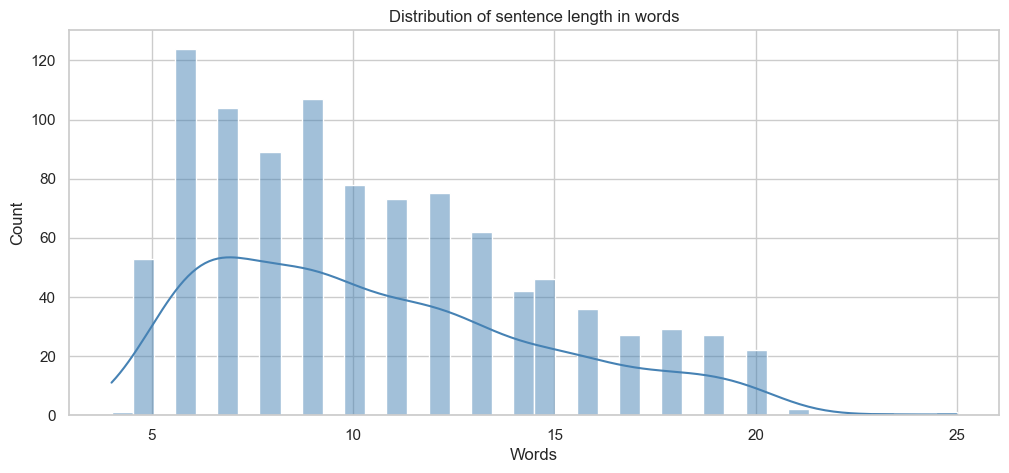

In [16]:
plt.figure(figsize=(12, 5))
sns.histplot(df["sentence_len_words"], bins=40, kde=True, color="steelblue")
plt.title("Distribution of sentence length in words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.savefig(str(output_dir / "sentence_length_words_distribution.png"))
plt.show()

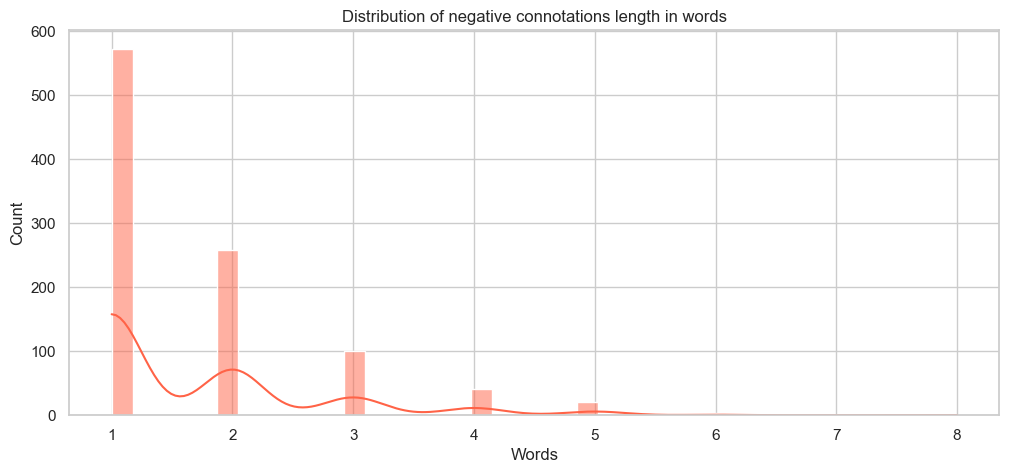

In [17]:
plt.figure(figsize=(12, 5))
sns.histplot(df["neg_len_words"], bins=40, kde=True, color="tomato")
plt.title("Distribution of negative connotations length in words")
plt.xlabel("Words")
plt.ylabel("Count")
plt.savefig(str(output_dir / "negative_connotations_length_words_distribution.png"))
plt.show()

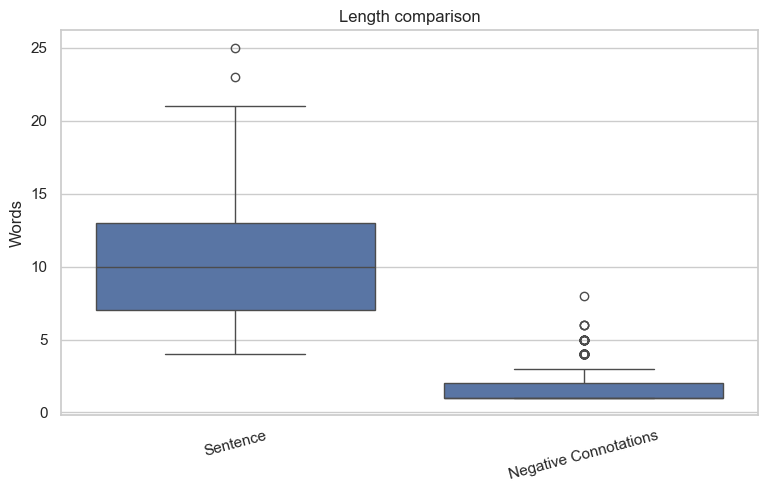

In [18]:
length_df = pd.DataFrame({
    "type": ["Sentence"] * len(df) + ["Negative Connotations"] * len(df),
    "length_words": list(df["sentence_len_words"]) + list(df["neg_len_words"])
})

plt.figure(figsize=(9, 5))
sns.boxplot(data=length_df, x="type", y="length_words")
plt.title("Length comparison")
plt.xlabel("")
plt.ylabel("Words")
plt.xticks(rotation=15)
plt.savefig(str(output_dir / "sentence_negative_length_comparison_boxplot.png"))
plt.show()

Анализ количества токсичных слов в одном примере

In [19]:
df["neg_count"] = df["Negative Connotations"].astype(str).apply(lambda x: len([i.strip() for i in x.split(",") if i.strip()]))
df["neg_count"].describe()

count    999.000000
mean       1.740741
std        0.933593
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: neg_count, dtype: float64

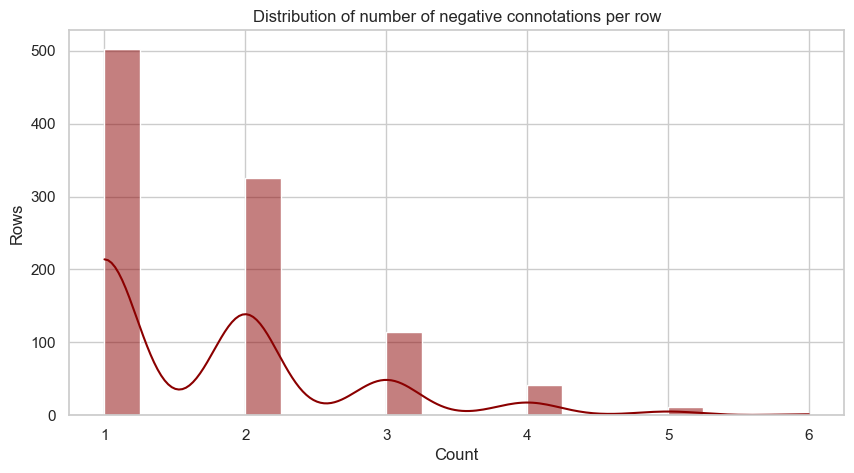

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(df["neg_count"], bins=20, kde=True, color="darkred")
plt.title("Distribution of number of negative connotations per row")
plt.xlabel("Count")
plt.ylabel("Rows")
plt.savefig(str(output_dir / "negative_connotations_count_distribution.png"))
plt.show()

Самые частые негативные слова

In [21]:
neg_words = []

for text in df["Negative Connotations"].astype(str):
    parts = [x.strip().lower() for x in text.split(",")]
    neg_words.extend([x for x in parts if x])

neg_counter = Counter(neg_words)

neg_top = pd.DataFrame(neg_counter.most_common(20), columns=["word", "count"])
neg_top

,word,count
0,сука,25
1,твари,19
2,блядь,19
3,тварь,15
4,дебилы,13
5,уроды,13
6,пидор,13
7,мразь,12
8,хуй,11
9,бля,11


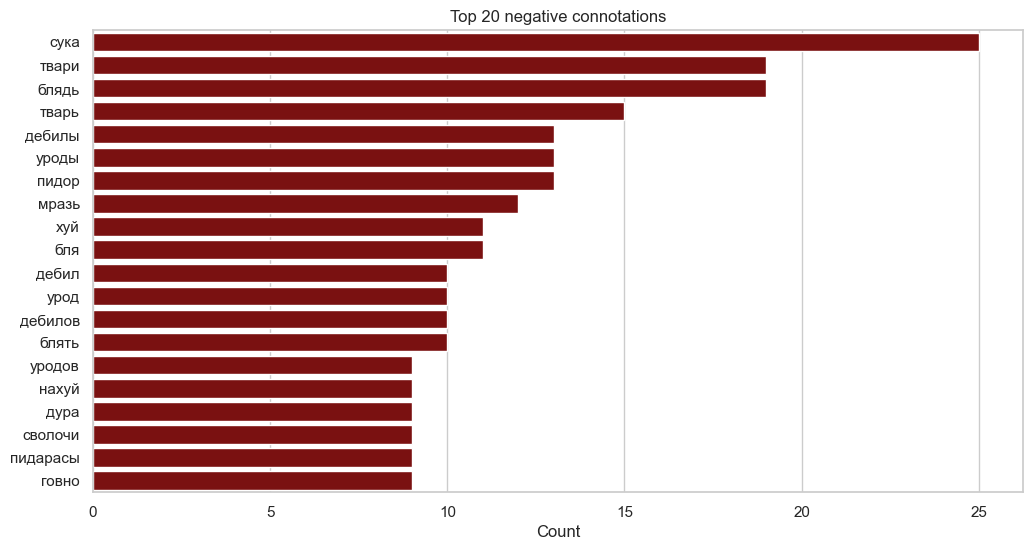

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(data=neg_top, y="word", x="count", color="darkred")
plt.title("Top 20 negative connotations")
plt.xlabel("Count")
plt.ylabel("")
plt.savefig(str(output_dir / "top_20_negative_connotations.png"))
plt.show()

Частотный анализ слов в самих предложениях

In [23]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^а-яёa-z0-9\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [24]:
df["sentence_clean"] = df["Sentence"].apply(preprocess_text)

In [25]:
sentence_words = " ".join(df["sentence_clean"]).split()
sentence_counter = Counter(sentence_words)

sentence_top = pd.DataFrame(sentence_counter.most_common(20), columns=["word", "count"])
sentence_top

,word,count
0,и,314
1,не,312
2,в,201
3,а,186
4,что,163
5,на,153
6,ты,123
7,это,108
8,с,94
9,как,88


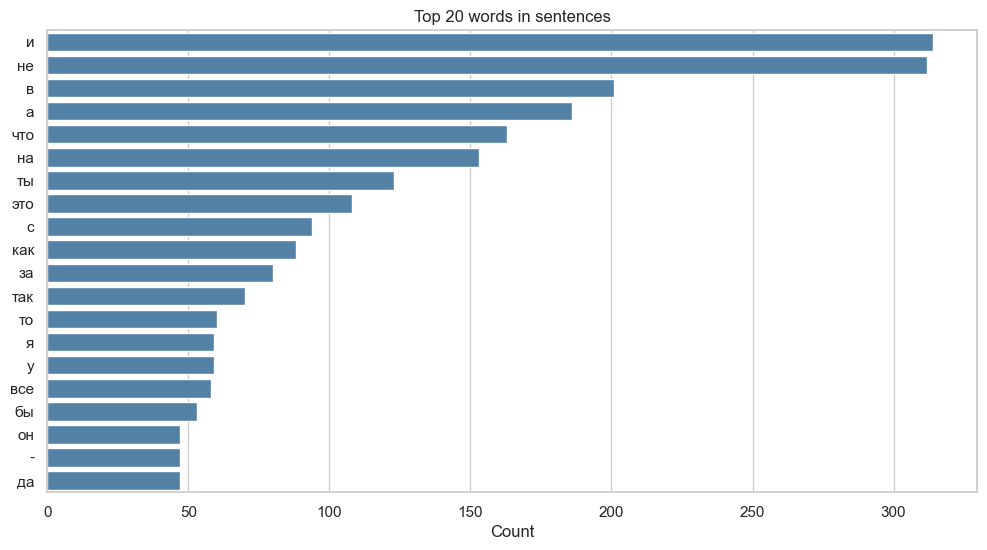

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(data=sentence_top, y="word", x="count", color="steelblue")
plt.title("Top 20 words in sentences")
plt.xlabel("Count")
plt.ylabel("")
plt.savefig(str(output_dir / "top_20_sentence_words.png"))
plt.show()

Биграммы в предложениях

In [27]:
def get_top_ngrams(text_series, n=2, top_k=20):
    vectorizer = CountVectorizer(ngram_range=(n, n))
    X = vectorizer.fit_transform(text_series)
    freqs = X.sum(axis=0).A1
    ngrams = vectorizer.get_feature_names_out()
    result = pd.DataFrame({"ngram": ngrams, "count": freqs})
    return result.sort_values("count", ascending=False).head(top_k)

In [28]:
top_bigrams = get_top_ngrams(df["sentence_clean"], n=2, top_k=20)
top_bigrams

,ngram,count
7756,что ты,10
6844,то что,10
7964,это не,8
7680,что за,7
2483,как ты,7
3744,не может,7
5164,потому что,7
7755,что то,7
7763,что это,6
1220,даже не,6


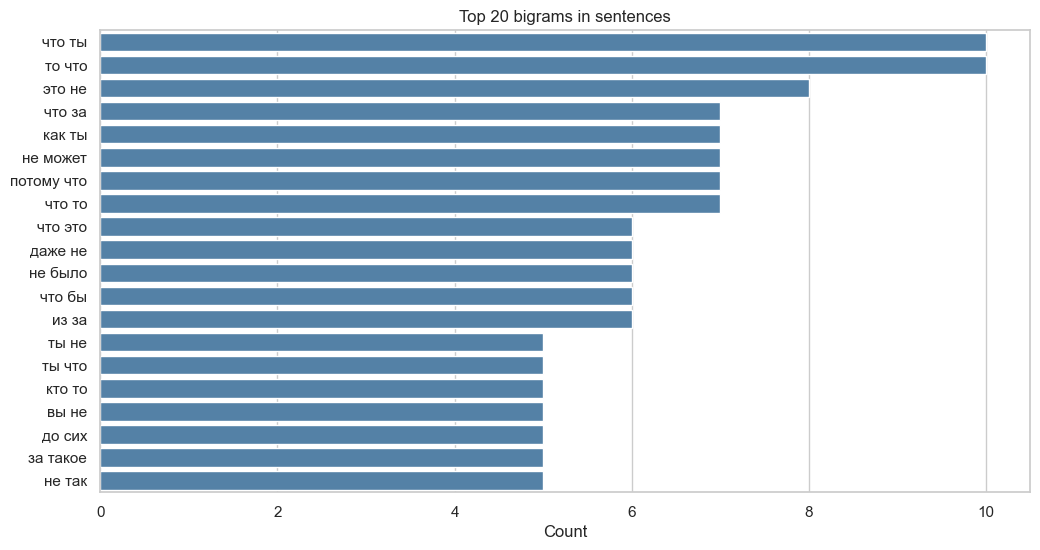

In [29]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_bigrams, y="ngram", x="count", color="steelblue")
plt.title("Top 20 bigrams in sentences")
plt.xlabel("Count")
plt.ylabel("")
plt.savefig(str(output_dir / "top_20_bigrams.png"))
plt.show()